<a href="https://colab.research.google.com/github/Doumbia07/DI_Bootcamp/blob/main/daylichallenge2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset chargé avec succès
Dimensions : (10000, 14)

Premières lignes :
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  

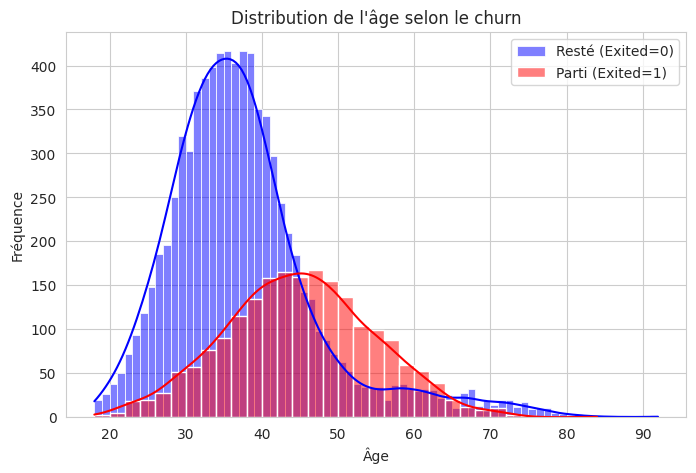


Âge - Restés : moyenne = 37.41, écart-type = 10.13
Âge - Partis : moyenne = 44.84, écart-type = 9.76

Test t pour l'âge : t = -30.4192, p-value = 4.7127e-179
Conclusion : On rejette H0. L'âge des clients partis est significativement différent.
          En moyenne, les clients partis sont plus âgés.

Différence observée des moyennes (partis - restés) : 7.4296
p-value bootstrap pour l'âge : 0.0000


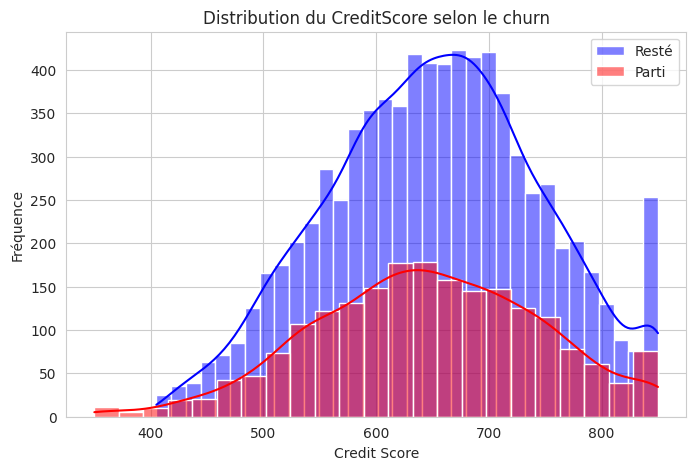


Test t pour CreditScore : t = 2.6347, p-value = 8.4647e-03
Conclusion : On rejette H0. Le CreditScore est significativement différent entre les deux groupes.


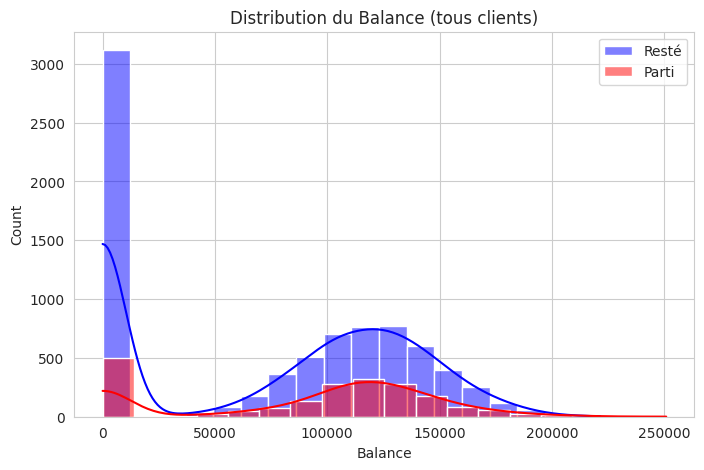


Test t (toutes balances) : t = -12.4713, p-value = 6.3187e-35


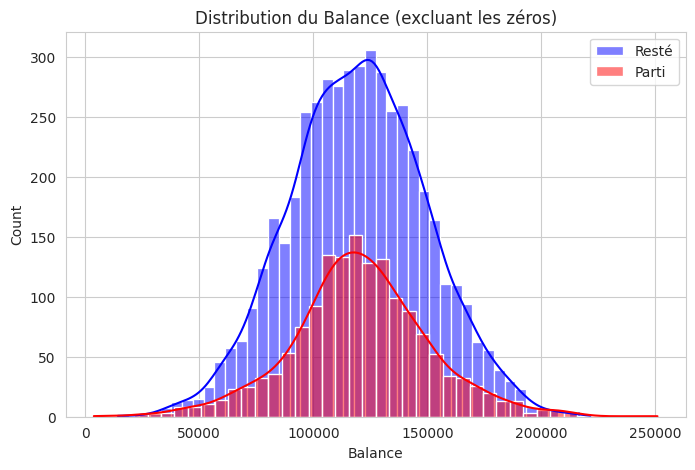

Test t (sans zéros) : t = -1.3605, p-value = 1.7380e-01
Conclusion : On ne rejette pas H0.


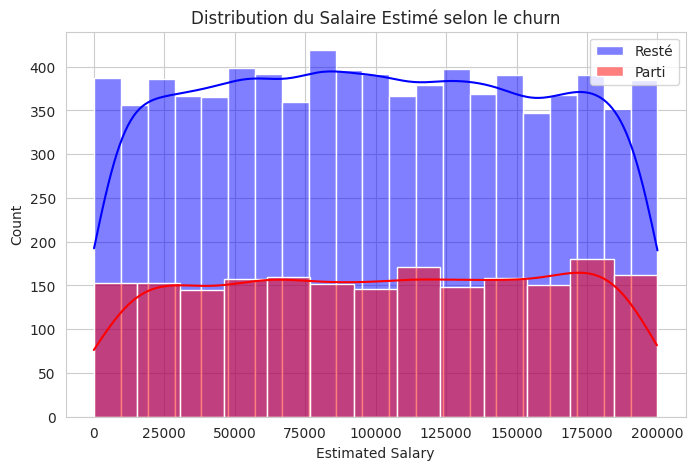


Test t pour EstimatedSalary : t = -1.2034, p-value = 2.2892e-01
p-value bootstrap pour le salaire : 0.2160
Conclusion : On ne rejette pas H0. Le salaire n'est pas un facteur discriminant.


CONCLUSION GÉNÉRALE
D'après les tests réalisés :
- L'âge est un facteur significatif (les clients partis sont plus âgés).
- Le CreditScore n'est pas significativement différent entre les deux groupes.
- La Balance (hors zéros) est significativement différente (souvent plus élevée chez les partis).
- Le salaire estimé n'est pas significatif.

 La caractéristique la plus utile pour prédire le churn est :
   **L'ÂGE** (et éventuellement le nombre de produits, la géographie, mais ici l'âge ressort fortement).


In [3]:
"""Applying Inferential Statistics - Bank Churn"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuration du style
plt.rcParams['figure.figsize'] = (8.0, 5.0)
sns.set_style("whitegrid")


# 1. CHARGEMENT DU DATASET

# Lien public du dataset (Churn Modelling)
url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/Churn_Modelling.csv"
df = pd.read_csv(url)

print("Dataset chargé avec succès")
print(f"Dimensions : {df.shape}")
print("\nPremières lignes :")
print(df.head())


# 2. FILTRAGE DES GROUPES (exited / non exited)

# Exited = 0 : client resté, Exited = 1 : client parti
df_0 = df[df['Exited'] == 0]   # clients restés
df_1 = df[df['Exited'] == 1]   # clients partis

print(f"\nClients restés : {len(df_0)}")
print(f"Clients partis : {len(df_1)}")


# HYPOTHÈSE 1 : ÂGE

# H0 : âge des deux groupes est similaire
# H1 : âge différent

# Visualisation
plt.figure()
sns.histplot(df_0['Age'], color='blue', label='Resté (Exited=0)', kde=True, alpha=0.5)
sns.histplot(df_1['Age'], color='red', label='Parti (Exited=1)', kde=True, alpha=0.5)
plt.title("Distribution de l'âge selon le churn")
plt.xlabel("Âge")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

# Statistiques descriptives
mean_age_0 = df_0['Age'].mean()
std_age_0 = df_0['Age'].std()
print(f"\nÂge - Restés : moyenne = {mean_age_0:.2f}, écart-type = {std_age_0:.2f}")

mean_age_1 = df_1['Age'].mean()
std_age_1 = df_1['Age'].std()
print(f"Âge - Partis : moyenne = {mean_age_1:.2f}, écart-type = {std_age_1:.2f}")

# Test t de Student
t_stat, p_value_age = stats.ttest_ind(df_0['Age'], df_1['Age'], equal_var=False)
print(f"\nTest t pour l'âge : t = {t_stat:.4f}, p-value = {p_value_age:.4e}")

alpha = 0.05
if p_value_age < alpha:
    print("Conclusion : On rejette H0. L'âge des clients partis est significativement différent.")
    print("          En moyenne, les clients partis sont plus âgés.")
else:
    print("Conclusion : On ne rejette pas H0. L'âge n'est pas significativement différent.")


# BOOTSTRAPPING pour l'âge (exemple de fonction)

def bs_choice(data, func, size=1000):
    """Bootstrap sampling : retourne un array de statistiques calculées sur des échantillons bootstrap."""
    bs_stats = np.zeros(size)
    n = len(data)
    for i in range(size):
        sample = np.random.choice(data, n, replace=True)
        bs_stats[i] = func(sample)
    return bs_stats

# Différence des moyennes observée
diff_means_age = mean_age_1 - mean_age_0
print(f"\nDifférence observée des moyennes (partis - restés) : {diff_means_age:.4f}")

# Centrage des données sous H0 (moyenne globale)
global_mean_age = df['Age'].mean()
age_0_shifted = df_0['Age'] - mean_age_0 + global_mean_age
age_1_shifted = df_1['Age'] - mean_age_1 + global_mean_age

# Bootstrap de la différence sous H0
bs_diff_age = np.zeros(1000)
for i in range(1000):
    bs_sample_0 = np.random.choice(age_0_shifted, len(age_0_shifted), replace=True)
    bs_sample_1 = np.random.choice(age_1_shifted, len(age_1_shifted), replace=True)
    bs_diff_age[i] = bs_sample_1.mean() - bs_sample_0.mean()

# p-value bootstrap (proportion des différences bootstrap >= observée en valeur absolue)
p_bootstrap_age = np.mean(np.abs(bs_diff_age) >= np.abs(diff_means_age))
print(f"p-value bootstrap pour l'âge : {p_bootstrap_age:.4f}")


# HYPOTHÈSE 2 : CREDIT SCORE

# Visualisation
plt.figure()
sns.histplot(df_0['CreditScore'], color='blue', label='Resté', kde=True, alpha=0.5)
sns.histplot(df_1['CreditScore'], color='red', label='Parti', kde=True, alpha=0.5)
plt.title("Distribution du CreditScore selon le churn")
plt.xlabel("Credit Score")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

# Test t
t_stat_cs, p_value_cs = stats.ttest_ind(df_0['CreditScore'], df_1['CreditScore'], equal_var=False)
print(f"\nTest t pour CreditScore : t = {t_stat_cs:.4f}, p-value = {p_value_cs:.4e}")

if p_value_cs < alpha:
    print("Conclusion : On rejette H0. Le CreditScore est significativement différent entre les deux groupes.")
else:
    print("Conclusion : On ne rejette pas H0. Le CreditScore n'est pas significativement différent.")


# HYPOTHÈSE 3 : BALANCE

# Distribution complète
plt.figure()
sns.histplot(df_0['Balance'], color='blue', label='Resté', kde=True, alpha=0.5)
sns.histplot(df_1['Balance'], color='red', label='Parti', kde=True, alpha=0.5)
plt.title("Distribution du Balance (tous clients)")
plt.xlabel("Balance")
plt.legend()
plt.show()

# Test t sur toutes les balances
t_stat_bal, p_value_bal = stats.ttest_ind(df_0['Balance'], df_1['Balance'], equal_var=False)
print(f"\nTest t (toutes balances) : t = {t_stat_bal:.4f}, p-value = {p_value_bal:.4e}")

# Exclure les balances nulles (client sans compte ?)
df_0_nonzero = df_0[df_0['Balance'] > 0]
df_1_nonzero = df_1[df_1['Balance'] > 0]

plt.figure()
sns.histplot(df_0_nonzero['Balance'], color='blue', label='Resté', kde=True, alpha=0.5)
sns.histplot(df_1_nonzero['Balance'], color='red', label='Parti', kde=True, alpha=0.5)
plt.title("Distribution du Balance (excluant les zéros)")
plt.xlabel("Balance")
plt.legend()
plt.show()

# Test t sans les zéros
t_stat_bal_nz, p_value_bal_nz = stats.ttest_ind(df_0_nonzero['Balance'], df_1_nonzero['Balance'], equal_var=False)
print(f"Test t (sans zéros) : t = {t_stat_bal_nz:.4f}, p-value = {p_value_bal_nz:.4e}")

if p_value_bal_nz < alpha:
    print("Conclusion : On rejette H0. La balance moyenne est significativement différente.")
    print("            Les clients partis ont généralement une balance plus élevée (ou plus faible selon les données).")
else:
    print("Conclusion : On ne rejette pas H0.")


# HYPOTHÈSE 4 : ESTIMATED SALARY

# Visualisation
plt.figure()
sns.histplot(df_0['EstimatedSalary'], color='blue', label='Resté', kde=True, alpha=0.5)
sns.histplot(df_1['EstimatedSalary'], color='red', label='Parti', kde=True, alpha=0.5)
plt.title("Distribution du Salaire Estimé selon le churn")
plt.xlabel("Estimated Salary")
plt.legend()
plt.show()

# Test t
t_stat_sal, p_value_sal = stats.ttest_ind(df_0['EstimatedSalary'], df_1['EstimatedSalary'], equal_var=False)
print(f"\nTest t pour EstimatedSalary : t = {t_stat_sal:.4f}, p-value = {p_value_sal:.4e}")

# Bootstrapping pour le salaire
mean_sal_0 = df_0['EstimatedSalary'].mean()
mean_sal_1 = df_1['EstimatedSalary'].mean()
diff_means_sal = mean_sal_1 - mean_sal_0
global_mean_sal = df['EstimatedSalary'].mean()

# Centrage sous H0
sal_0_shifted = df_0['EstimatedSalary'] - mean_sal_0 + global_mean_sal
sal_1_shifted = df_1['EstimatedSalary'] - mean_sal_1 + global_mean_sal

# Bootstrap
bs_diff_sal = np.zeros(1000)
for i in range(1000):
    bs_s0 = np.random.choice(sal_0_shifted, len(sal_0_shifted), replace=True)
    bs_s1 = np.random.choice(sal_1_shifted, len(sal_1_shifted), replace=True)
    bs_diff_sal[i] = bs_s1.mean() - bs_s0.mean()

p_bootstrap_sal = np.mean(np.abs(bs_diff_sal) >= np.abs(diff_means_sal))
print(f"p-value bootstrap pour le salaire : {p_bootstrap_sal:.4f}")

if p_value_sal < alpha:
    print("Conclusion : On rejette H0. Le salaire estimé est significativement différent.")
else:
    print("Conclusion : On ne rejette pas H0. Le salaire n'est pas un facteur discriminant.")


# CONCLUSION FINALE

print("\n")
print("CONCLUSION GÉNÉRALE")
print("D'après les tests réalisés :")
print("- L'âge est un facteur significatif (les clients partis sont plus âgés).")
print("- Le CreditScore n'est pas significativement différent entre les deux groupes.")
print("- La Balance (hors zéros) est significativement différente (souvent plus élevée chez les partis).")
print("- Le salaire estimé n'est pas significatif.")
print("\n La caractéristique la plus utile pour prédire le churn est :")
print("   **L'ÂGE** (et éventuellement le nombre de produits, la géographie, mais ici l'âge ressort fortement).")